<!-- AUTOGENERATED-DOCS -->
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/BAMresearch/NFDI4IngModelValidationPlatform/main?labpath=notebooks%2Fplate_with_hole_fenics.ipynb)

# Infinite linear elastic plate with hole

# I make a change here

## Problem description

We consider the case of an infinite plate with a circular hole with radius $a$ in the center. The plate is subjected to uniform tensile load $p$ at infinity. The analytical solution for the stress field has been derived by Kirsch in 1898 [@Kirsch1898].
<!-- include an svg picture here-->
![Infinite linear elastic plate with hole](https://raw.githubusercontent.com/BAMresearch/NFDI4IngModelValidationPlatform/main/docs/benchmarks/linear%20elasticity/plate-with-hole.svg)

The solution is given in polar stress components of the Cauchy stress tensor $\boldsymbol \sigma$ at a point with polar coordinates $(r,\theta)\in\mathbb R_+ \times \mathbb R$. Assume that the infinite plate is loaded in $x$-direction with load $p$, then the polar stress components are given by

$$
    \begin{aligned}
        \sigma_{rr}(r,\theta) &= \frac{p}{2}\left(1-\frac{a^2}{r^2}\right)+\frac{p}{2}\left(1-\frac{a^2}{r^2}\right)\left(1-\frac{3a^2}{r^2}\right)\cos(2\theta)\\
        \sigma_{\theta\theta}(r,\theta) &=\frac{p}{2}\left(1+\frac{a^2}{r^2}\right) - \frac{p}{2}\left(1+\frac{3a^4}{r^4}\right)\cos(2\theta)\\
        \sigma_{r\theta}(r,\theta) &= -\frac{p}{2}\left(1-\frac{a^2}{r^2}\right)\left(1+\frac{3a^2}{r^2}\right)\sin(2\theta)
    \end{aligned}
$$

In order to write the stresses in a cartesian coordiante system, they need to be rotated by $\theta$, which results in

$$
    \begin{aligned}
        \sigma_{xx} (r,\theta) &=  \frac{3 a^{4} p \cos{\left(4 \theta \right)}}{2 r^{4}} - \frac{a^{2} p \left(1.5 \cos{\left(2 \theta \right)} + \cos{\left(4 \theta \right)}\right)}{r^{2}} + p \\
        \sigma_{yy} (r,\theta)&= - \frac{3 a^{4} p \cos{\left(4 \theta \right)}}{2 r^{4}} - \frac{a^{2} p \left(\frac{\cos{\left(2 \theta \right)}}{2} - \cos{\left(4 \theta \right)}\right)}{r^{2}}\\
        \sigma_{xy} (r,\theta) &= \frac{3 a^{4} p \sin{\left(4 \theta \right)}}{2 r^{4}} - \frac{a^{2} p \left(\frac{\sin{\left(2 \theta \right)}}{2} + \sin{\left(4 \theta \right)}\right)}{r^{2}}
    \end{aligned}
$$

with the full stress tensor solution given by

$$
\boldsymbol\sigma_\mathrm{analytical} (r,\theta)= \begin{bmatrix} \sigma_{xx}(r,\theta) & \sigma_{xy}(r,\theta)\\\ \sigma_{xy}(r,\theta) & \sigma_{yy}(r,\theta) \end{bmatrix}.
$$

or for a cartesion point $(x,y)\in \mathbb R_+^2$:

$$
\boldsymbol\sigma_\mathrm{analytical} (x,y)=\boldsymbol\sigma_\mathrm{analytical} \left(\sqrt{x^2 + y^2},\arccos\frac{x}{\sqrt{x^2+y^2}}\right). 
$$

In order to transform this into a practical benchmark, we consider a rectangular subdomain
of the infinite plate around the hole. The boundary conditions of the subdomain are determined
from the analytical solution. The example is further reduced by only simulating one quarter
of the rectangular domain with length $l$ and assuming symmetry conditions at the edges. Let 

$$
\Omega =[0,l]^2 \setminus \lbrace (x,y) \mid \sqrt{x^2+y^2}<a \rbrace
$$ 

be the domain of the benchmark example and

$$
\begin{aligned}
\Gamma_\mathrm{D_1} &= \lbrace (x,y)\in \partial\Omega | y=0\rbrace \\
\Gamma_\mathrm{D_2} &= \lbrace (x,y)\in \partial\Omega | x=0\rbrace \\
\Gamma_\mathrm{N} &= \lbrace (x,y)\in \partial\Omega | x=l \lor y=l \rbrace
\end{aligned}
$$

then the PDE with the displacement $\boldsymbol u$ as solution variable is given by

$$
\begin{aligned}
\mathrm{div}\boldsymbol{\sigma}(\boldsymbol{\varepsilon}(\boldsymbol{u})) &= 0 &\quad \text{ on } \Omega & \\
\boldsymbol{\varepsilon}(\boldsymbol u) &= \frac{1}{2}\left(\nabla \boldsymbol u + (\nabla\boldsymbol u)^\top\right) &&\text{Infinitesimal strain}\\
\boldsymbol{\sigma}(\boldsymbol{\varepsilon}) &= \frac{E}{1-\nu^2}\left((1-\nu)\boldsymbol{\varepsilon} + \nu \mathrm{tr}\boldsymbol{\varepsilon}\boldsymbol I_2\right) && \text{Plane stress law}\\
\boldsymbol u_y &=0 & \text{ on } \Gamma_\mathrm{D_1}& \text{ Dirichlet BC}\\
\boldsymbol u_x &=0 & \text{ on } \Gamma_\mathrm{D_2}& \text{ Dirichlet BC}\\
\boldsymbol t &= \tilde{\boldsymbol{t}} & \text{ on } \Gamma_\mathrm{N} & \text{ Neumann BC}\\
\end{aligned}
$$

with the material parameters $E,\nu$ -- the Youngs modulus and Poisson ratio. The traction $\boldsymbol t$ is the Cauchy stress tensor multiplied by the normal vector on the boundary $\boldsymbol \sigma \cdot \boldsymbol n$. Prescribing a value $\tilde{\boldsymbol t}$ on a subset of the boundary $\partial\Omega$ is referred to as a Neumann boundary condition in computational mechanics. In this specific example, 

$$
\tilde{\boldsymbol t} =\boldsymbol\sigma_\mathrm{analytical} \cdot \boldsymbol{n}.
$$

## Weak formulation and numerical solution

In the weak formulation of the problem, we want to find $\boldsymbol u$ such that

$$
B(\boldsymbol u,\boldsymbol v) = f(\boldsymbol{v}) \quad \forall \boldsymbol v 
$$

with a test function $\boldsymbol{v}$ and 

$$
\begin{aligned}
B(\boldsymbol u,\boldsymbol v) &= \int_{\Omega} \boldsymbol\varepsilon(\boldsymbol{v}) : \boldsymbol{\sigma}(\boldsymbol{\varepsilon}(\boldsymbol{u})) \mathrm{d}{\boldsymbol{x}} \\
    f(\boldsymbol v)&=\int_{\Gamma_{\mathrm{N}}} {\boldsymbol{t}}\cdot\boldsymbol{v}\mathrm{d}{\boldsymbol{s}}.
\end{aligned}
$$


In order to solve the weak formulation, the finite-element method (FEM) can be used. This method discretizes the domain $\Omega$ into so called finite elements that can for example be triangles or quadrilaterals in 2D. On these elements, ansatz functions are defined such that they are continous on the boundaries between elements. These functions form a basis for the solution space for an approximate solution $\boldsymbol{u}_h$ of the problem.

## Comparison of approximate solution with analytical solution

The approxiamte solution and the analytical solution can be compared with the $L_2$ norm which is defined as

$$
\Vert \boldsymbol{u}\Vert_{L_2} = \sqrt{\int_\Omega \Vert\boldsymbol{u}(\boldsymbol{x})\Vert_2^2 \mathrm d \boldsymbol x}
$$

and the error in the $L_2$ norm

$$
e_{L_2} = \Vert \boldsymbol{u}-\boldsymbol{u}_h\Vert_{L_2}.
$$

Alternatively, the sup norm can be used which is defined as

$$
\Vert \boldsymbol{u}\Vert_{\inf} = \sup_{\boldsymbol x} \Vert \boldsymbol{u}(\boldsymbol{x}) \Vert
$$

and the error in the sup norm

$$
e_{\inf} = \Vert \boldsymbol{u}-\boldsymbol{u}_h\Vert_{\inf}.
$$


With these metrices, we can perform a convergence analysis for different approximations $\boldsymbol{u}_h$ which differ in the element size $h$. Plotting the error over the used element-size in a log-log plot lets us determine the convergence order of the approximation.

## Table of parameters

### Model parameters
| Parameter    | Description                     |
| ------------ | ------------------------------  |
| $a$[m]   | Radius of the hole.             |
| $l$[m]   | Length of the benchmark domain. |
| $E$[Pa]  | Youngs modulus.                 |
| $\nu$[-]  | Poisson ratio.                  |
| $p$[Pa]  | Load at infinity.               |

### Numerical parameters

| Parameter    | Description                     |
| ------------ | ------------------------------  |
| $h$[m]   | Element size.                        |
| $q$[-] | Element order, i.e. the geometry interpolation order (curved edges or linear edges). |
| $p$[-]  | Degree of the ansatz functions.           |
| $r$[-]  | Degree of the quadrature rule, meaning the polynomial degree which is still integrated exactly.      |
| $\mathcal Q$[-]  | Quadrature rule (e.g. Gauss or Gauss-Lobatto).               |


## Numerical Results

### FEniCS

[![Jupyter4NFDI](https://nfdi-jupyter.de/images/jupyter4nfdi_badge.svg)](https://hub.nfdi-jupyter.de/v2/gh/BAMresearch/NFDI4IngModelValidationPlatform/HEAD?labpath=notebooks%2Fplate_with_hole_fenics.ipynb)

### Kratos

[![Jupyter4NFDI](https://nfdi-jupyter.de/images/jupyter4nfdi_badge.svg)](https://hub.nfdi-jupyter.de/v2/gh/BAMresearch/NFDI4IngModelValidationPlatform/HEAD?labpath=notebooks%2Fplate_with_hole_Kratos.ipynb)

# Postprocessing for FEniCSx example

In [ ]:
import json

import pyvista
from pathlib import Path
import xml.etree.ElementTree as ET
import meshio
import numpy as np
import pint

ureg = pint.UnitRegistry()

class AnalyticalSolution:
    def __init__(self, E, nu, radius, L, load):
        self.radius = radius
        self.L = L
        self.load = load
        self.E = E
        self.nu = nu

    def polar(self, x):
        r = np.hypot(x[0], x[1])
        theta = np.atan2(x[1], x[0])
        return r, theta

    def displacement(self, x):
        r, theta = self.polar(x)
        a = self.radius

        T = self.load
        Ta_8mu = T * a / (4 * self.E / (1.0 + 1.0 * self.nu))
        k = (3.0 - self.nu) / (1.0 + self.nu)

        ct = np.cos(theta)
        c3t = np.cos(3 * theta)
        st = np.sin(theta)
        s3t = np.sin(3 * theta)

        fac = 2 * np.pow(a / r, 3)

        ux = Ta_8mu * (
            r / a * (k + 1.0) * ct + 2.0 * a / r * ((1.0 + k) * ct + c3t) - fac * c3t
        )

        uy = Ta_8mu * (
            (r / a) * (k - 3.0) * st + 2.0 * a / r * ((1.0 - k) * st + s3t) - fac * s3t
        )

        return ux, uy, np.zeros_like(ux)

    def stress(self, x):
        r, theta = self.polar(x)
        T = self.load
        a = self.radius
        cos2t = np.cos(2 * theta)
        cos4t = np.cos(4 * theta)
        sin2t = np.sin(2 * theta)
        sin4t = np.sin(4 * theta)

        fac1 = (a * a) / (r * r)
        fac2 = 1.5 * fac1 * fac1

        sxx = T - T * fac1 * (1.5 * cos2t + cos4t) + T * fac2 * cos4t
        syy = -T * fac1 * (0.5 * cos2t - cos4t) - T * fac2 * cos4t
        sxy = -T * fac1 * (0.5 * sin2t + sin4t) + T * fac2 * sin4t

        return sxx, sxy, sxy, syy
    
    def mises_stress(self, x):
        sxx, sxy, _, syy = self.stress(x)
        
        return np.sqrt(
            0.5 * (
                (sxx - syy) ** 2 + sxx ** 2 + syy ** 2 + 6.0 * sxy ** 2
            )
        )

class Benchmark:
    def __init__(self, summary_file):
        root_path = Path(summary_file).parent
        with open(summary_file, "r") as f:
            self.summary = json.load(f)
        self.name = self.summary["name"]
        with open(root_path / self.summary["parameters"], "r") as f:
            self.parameters = json.load(f)
        with open(root_path / self.summary["input"], "r") as f:
            self.input = json.load(f)
        self.output = root_path / self.summary["output"]

    def read_output(self):
        if self.output.suffix == ".vtu":
            return pyvista.read(self.output)
        elif self.output.suffix == ".vtk":
            tree = ET.parse(self.output)
            root = tree.getroot()
            pvtu_filenames = []
            for dataset in root.findall(".//DataSet"):
                pvtu_filenames.append(dataset.get("file"))
            return [pyvista.read(self.output.parent / pvtu_filename) for pvtu_filename in pvtu_filenames]
        elif self.output.suffix == ".pvtu":
            return pyvista.read(self.output)
    def get_vtu(self):
        if self.output.suffix == ".vtu":
            return self.output
        elif self.output.suffix == ".vtk":
            tree = ET.parse(self.output)
            root = tree.getroot()
            for dataset in root.findall(".//DataSet"):
                pvtu_filename = self.output.parent / dataset.get("file")
            #return meshio.read(self.output.parent / pvtu_filename)
        elif self.output.suffix == ".pvtu":
            pvtu_filename = self.output
        
        # Load and parse the XML file
        tree = ET.parse(pvtu_filename)
        root = tree.getroot()

        # Find the Piece element and get the Source attribute
        piece_element = root.find('.//Piece')
        vtu_filename = piece_element.get('Source')

        return self.output.parent / vtu_filename
            
    def __repr__(self):
        return f"{self.name}: {self.parameters}"


directory = "../../../benchmarks/linear-elasticity-plate-with-hole/"
file_names = list(Path(directory).rglob("summary_*.json"))

# read the parameters
benchmarks = []
for file_name in file_names:
    benchmarks.append(Benchmark(file_name))

# Search for parameters where element-degree == 1 and the element-size differs
benchmarks = filter(
    lambda b: b.parameters["element-degree"] == 1
    and b.parameters["element-order"] == 1,
    benchmarks,
)
benchmarks_sorted = sorted(
    benchmarks, key=lambda b: b.parameters["element-size"]["value"], reverse=True
)
benchmarks_sorted
parameters = benchmarks_sorted[0].parameters
without_unit = {}

for key, value in parameters.items():
    try:
        without_unit[key] = ureg.Quantity(value["value"], value["unit"]).to_base_units().magnitude
    except TypeError:
        pass

analytical_solution = AnalyticalSolution(without_unit["young-modulus"], without_unit["poisson-ratio"], without_unit["radius"], without_unit["length"], without_unit["load"])

In [2]:
import meshhelper
from mpi4py import MPI
h = [b.parameters["element-size"]["value"] for b in benchmarks_sorted]
data = [b.read_output() for b in benchmarks_sorted]
data_u = [datapoint[i] for datapoint in data for i in range(0, len(datapoint)) if "u" in datapoint[i].array_names]
data_stress = [datapoint[i] for datapoint in data for i in range(0, len(datapoint)) if "stress" in datapoint[i].array_names]
data_dolfinx_u = [meshhelper.io.pyvista_mesh_to_dolfinx(MPI.COMM_SELF, datapoint, ["u"]) for datapoint in data_u]
data_dolfinx_stress = [meshhelper.io.pyvista_mesh_to_dolfinx(MPI.COMM_SELF, datapoint, ["stress"]) for datapoint in data_stress]

In [3]:
import dolfinx as df
import numpy as np
interpolated_data_inf = []
interpolated_data_l2 = []
for i in range(len(data_dolfinx_u)):
    fun_tmp = df.fem.Function(data_dolfinx_u[i][1]["u"].function_space)
    high_order_space = df.fem.functionspace(fun_tmp.function_space.mesh, ("CG", 3, (3,)))
    fun_tmp_high_order = df.fem.Function(high_order_space)
    fun_tmp_high_order.interpolate(lambda x: analytical_solution.displacement(x))
    fun_tmp_high_order.x.scatter_forward()
    fun_tmp.interpolate(lambda x: analytical_solution.displacement(x))
    fun_tmp.x.scatter_forward()
    interpolated_data_inf.append(fun_tmp)
    interpolated_data_l2.append(fun_tmp_high_order)

In [4]:
error_l2 = []
error_inf = []
import ufl

for i in range(len(data_dolfinx_u)):
    diff_l2 = data_dolfinx_u[i][1]["u"] - interpolated_data_l2[i]
    error_inf.append(np.linalg.norm( data_dolfinx_u[i][1]["u"].x.array - interpolated_data_inf[i].x.array, np.inf))
    error_l2_squared = df.fem.assemble_scalar(df.fem.form((ufl.inner(diff_l2,diff_l2)) * ufl.dx))
    error_l2.append(np.sqrt(error_l2_squared))

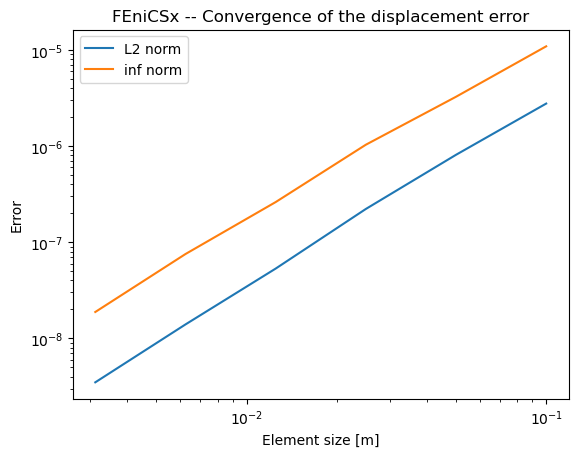

In [5]:
import matplotlib.pyplot as plt
plt.plot(h, error_l2, label="L2 norm")
plt.plot(h, error_inf, label="inf norm")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Element size [m]")
plt.ylabel("Error")
plt.title("FEniCSx -- Convergence of the displacement error")
plt.legend()

In [6]:
for datapoint in data_stress:
    trace = datapoint["stress"][:,0] + datapoint["stress"][:,3]
    stress_dev = np.array(datapoint["stress"])
    stress_dev[:,0] -= trace/3.0
    stress_dev[:,3] -= trace/3.0

    datapoint["mises_stress"] = np.sqrt((3.0/2.0) * (np.sum(stress_dev**2, axis=1) + (trace/3.0)**2.0))

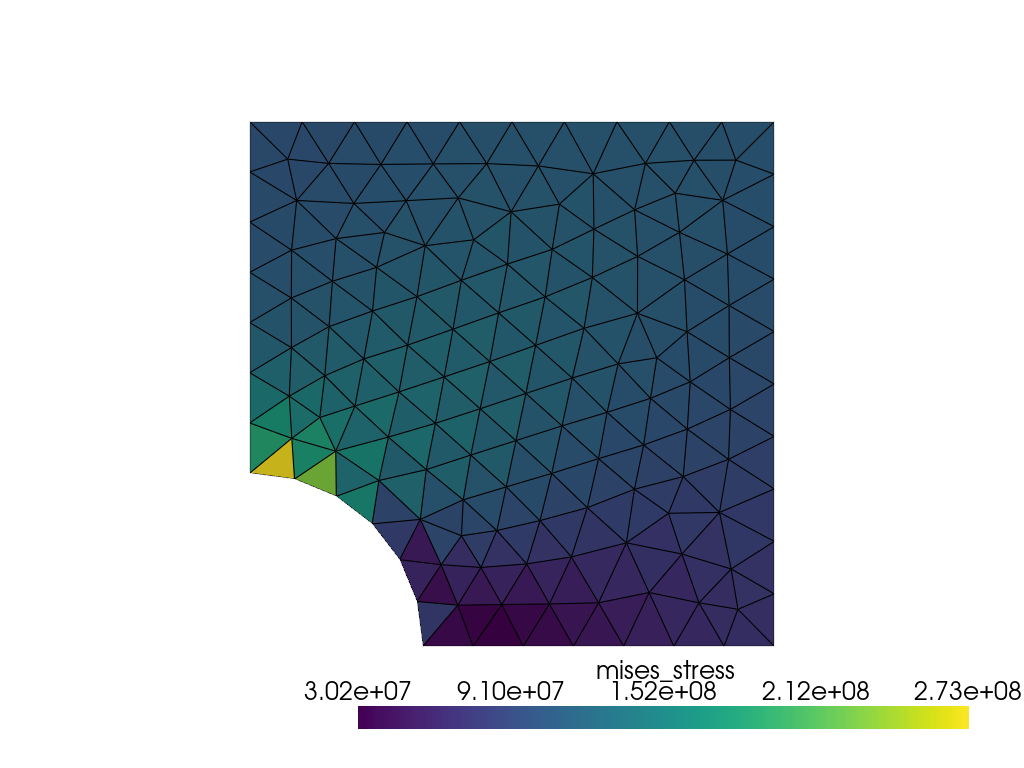

In [7]:
pyvista.global_theme.font.label_size = 25
pyvista.global_theme.font.title_size = 25
plotter = pyvista.Plotter()
plotter.add_mesh(data_stress[0], scalars="mises_stress", show_edges=True)
plotter.view_xy()

plotter.show()

In [8]:
interpolated_data_mises_inf = []
error_mises_inf = [] 
error_rel_mises_inf = []
norm_inf = []
for i in range(len(data_stress)):
    points = data_stress[i].cell_centers().points
    mises_analytical = analytical_solution.mises_stress((points[:,0], points[:,1]))
    error_mises_inf.append(np.linalg.norm(data_stress[i]["mises_stress"] - mises_analytical, np.inf))
    norm_inf.append(np.linalg.norm(mises_analytical, np.inf))
    error_rel_mises_inf.append(error_mises_inf[-1]/norm_inf[-1])
    mises_space = df.fem.functionspace(data_dolfinx_stress[i][1]["stress"].function_space.mesh, ("CG", 3))
    fun_tmp = df.fem.Function(data_dolfinx_stress[i][1]["stress"].function_space)


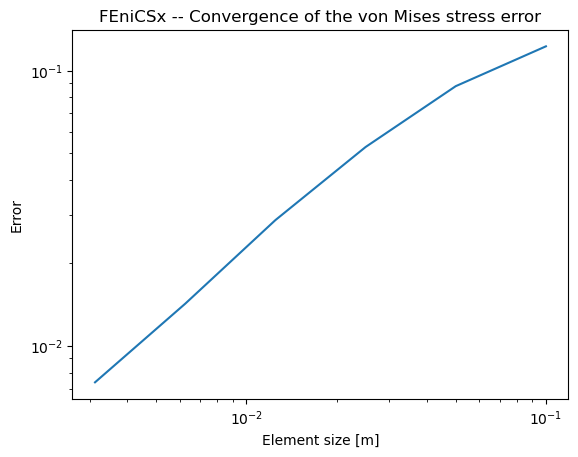

In [9]:
plt.plot(h, error_rel_mises_inf)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Element size [m]")
plt.ylabel("Error")
plt.title("FEniCSx -- Convergence of the von Mises stress error")
plt.show()